# ASO design and ranking demo (public data) - Google Colab version

Everything runs in your browser. Run the cells from top to bottom (click a cell, press Shift+Enter).

Tiles candidate antisense oligonucleotides (ASOs) across a region of a public NCBI transcript and ranks them by target accessibility,
predicted hybridisation energy, ASO self-structure and sequence flags. A screening heuristic, not a validated design tool.

## 1. Install (about 1 minute)

In [1]:
!pip -q install ViennaRNA biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 61.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 90.2 MB/s eta 0:00:00


## 2. Write the toolkit file into this session

In [5]:
%%writefile aso_toolkit.py
"""
aso_toolkit.py - a small, transparent antisense oligonucleotide (ASO) design demo.

Built from scratch on PUBLIC sequence data (NCBI). It tiles candidate ASOs across
a target region and ranks them on four things: target-site accessibility, predicted
hybridisation energy, ASO self-structure, and simple sequence-quality flags.

IMPORTANT: this is a computational screening heuristic, not a validated design tool.
ViennaRNA uses RNA energy parameters; DNA/RNA hybrids and modified chemistries
(2'-MOE, PMO, LNA...) behave differently. Treat scores as a way to prioritise
candidates for experiments, never as proof of efficacy.
"""
import random
import numpy as np
import pandas as pd
import RNA

_COMP = {"A": "T", "T": "A", "G": "C", "C": "G", "U": "A", "N": "N"}


def revcomp_dna(seq: str) -> str:
    """Reverse complement, returned as DNA (A/C/G/T)."""
    return "".join(_COMP[b] for b in reversed(seq.upper()))


def to_rna(seq: str) -> str:
    return seq.upper().replace("T", "U")


def gc_percent(seq: str) -> float:
    s = seq.upper()
    return 100.0 * (s.count("G") + s.count("C")) / len(s)


# ---------------------------------------------------------------- data access
def fetch_genbank(accession: str, email: str):
    """Download a GenBank record from NCBI (needs internet + an email for Entrez)."""
    from Bio import Entrez, SeqIO
    Entrez.email = email
    with Entrez.efetch(db="nucleotide", id=accession, rettype="gb", retmode="text") as h:
        return SeqIO.read(h, "genbank")


def list_exons(record):
    """List exon features as (number, start_1based, end_1based) in record coordinates."""
    exons = [f for f in record.features if f.type == "exon"]
    return [(i + 1, int(f.location.start) + 1, int(f.location.end)) for i, f in enumerate(exons)]


def demo_transcript(length: int = 500, seed: int = 7) -> str:
    """Random RNA used ONLY to test the pipeline offline. Not biological data."""
    rng = random.Random(seed)
    return "".join(rng.choice("ACGU") for _ in range(length))


# ------------------------------------------------------------------ structure
def unpaired_probabilities(rna: str) -> np.ndarray:
    """Per-nucleotide probability of being unpaired (ViennaRNA partition function)."""
    fc = RNA.fold_compound(rna)
    fc.mfe()
    fc.pf()
    bpp = fc.bpp()
    n = len(rna)
    up = np.ones(n)
    for i in range(1, n + 1):
        row = bpp[i]
        for j in range(i + 1, n + 1):
            p = row[j]
            if p > 0:
                up[i - 1] -= p
                up[j - 1] -= p
    return np.clip(up, 0.0, 1.0)


def aso_self_mfe(aso_dna: str) -> float:
    """Self-folding free energy of the ASO using DNA (Mathews 2004) parameters."""
    RNA.params_load_DNA_Mathews2004()
    try:
        _, mfe = RNA.fold(to_rna(aso_dna))
    finally:
        RNA.params_load_RNA_Turner2004()
    return float(mfe)


def hybrid_energy(aso_dna: str, target_rna: str) -> float:
    """Best duplex energy between ASO (as RNA) and its target site. RNA-parameter proxy."""
    res = RNA.duplexfold(to_rna(aso_dna), target_rna)
    return float(res.energy)


# -------------------------------------------------------------------- pipeline
def design_asos(transcript_rna: str, win_start: int, win_end: int,
                aso_len: int = 20, flank: int = 100) -> pd.DataFrame:
    """
    Tile ASOs across transcript[win_start:win_end] (1-based, inclusive) and score them.
    Accessibility is computed on the window plus `flank` nt of context on each side,
    because local folding context changes which sites are open.
    """
    t = to_rna(transcript_rna)
    ctx_start = max(1, win_start - flank)
    ctx_end = min(len(t), win_end + flank)
    context = t[ctx_start - 1:ctx_end]
    unpaired = unpaired_probabilities(context)

    rows = []
    for s in range(win_start, win_end - aso_len + 2):
        e = s + aso_len - 1
        site = t[s - 1:e]
        aso = revcomp_dna(site)
        access = float(unpaired[s - ctx_start:e - ctx_start + 1].mean())
        gc = gc_percent(aso)
        flags = []
        if "GGGG" in aso:
            flags.append("GGGG")
        if any(b * 5 in aso for b in "ACGT"):
            flags.append("homopolymer5")
        cpg = aso.count("CG")
        if cpg >= 2:
            flags.append(f"CpGx{cpg}")
        rows.append({
            "site_start": s, "site_end": e, "aso_5to3": aso, "gc_pct": round(gc, 1),
            "accessibility": round(access, 3),
            "hybrid_dG": round(hybrid_energy(aso, site), 1),
            "self_mfe": round(aso_self_mfe(aso), 1),
            "flags": ",".join(flags),
        })
    df = pd.DataFrame(rows)
    return score_candidates(df)


def score_candidates(df: pd.DataFrame) -> pd.DataFrame:
    """
    Transparent 0-100 score:
      40 pts  target accessibility (mean unpaired probability of the site)
      25 pts  hybrid strength (more negative dG = better, min-max scaled)
      20 pts  GC content (full marks 40-60%, linear falloff to 0 at 25/75%)
      15 pts  low ASO self-structure (full marks if self_mfe >= -1, 0 at <= -6)
      -10     if GGGG present (quadruplex / synthesis risk)
    """
    d = df.copy()
    dg = d["hybrid_dG"]
    span = dg.max() - dg.min()
    strength = (dg.max() - dg) / span if span > 0 else 0.5
    gc_pts = (1 - (abs(d["gc_pct"] - 50) - 10).clip(lower=0) / 15).clip(lower=0)
    self_pts = ((d["self_mfe"] + 6) / 5).clip(0, 1)
    score = 40 * d["accessibility"] + 25 * strength + 20 * gc_pts + 15 * self_pts
    score -= 10 * d["flags"].str.contains("GGGG").astype(int)
    d["score"] = score.round(1)
    d = d.sort_values("score", ascending=False).reset_index(drop=True)
    d.insert(0, "rank", d.index + 1)
    return d


# -------------------------------------------------------------------- plotting
def plot_results(df: pd.DataFrame, top_n: int = 10):
    import matplotlib.pyplot as plt
    top = df.head(top_n)
    fig, ax = plt.subplots(1, 2, figsize=(13, 4.2))
    ax[0].scatter(df["site_start"], df["accessibility"], s=14, c="#9aa5b1", label="all candidates")
    ax[0].scatter(top["site_start"], top["accessibility"], s=45, c="#c0392b", label=f"top {top_n}")
    ax[0].set_xlabel("Target site start (transcript position)")
    ax[0].set_ylabel("Mean unpaired probability")
    ax[0].set_title("Target accessibility across the window")
    ax[0].legend(frameon=False)
    labels = [f"{a}-{b}" for a, b in zip(top["site_start"], top["site_end"])]
    ax[1].barh(labels[::-1], top["score"][::-1], color="#1F3A5F")
    ax[1].set_xlabel("Composite score (0-100)")
    ax[1].set_title(f"Top {top_n} ASO candidates")
    fig.tight_layout()
    return fig


Overwriting aso_toolkit.py


## 3. Settings

In [6]:
import aso_toolkit as a

ACCESSION   = "NM_004006.3"        # human DMD mRNA (RefSeq). Change to any transcript you want to study.
EMAIL       = "mdmahfoozkhan148@gmail.com"    # put your real email: NCBI asks for one
EXON_NUMBER = None                 # set an exon number from the printed list, or leave None and use WINDOW
WINDOW      = (1000, 1150)         # (start, end) 1-based transcript positions, used if EXON_NUMBER is None
ASO_LEN     = 20
FLANK       = 100
USE_OFFLINE_DEMO = False          # True = random test sequence (pipeline check only, NOT biology)

## 4. Load the transcript

In [7]:
if USE_OFFLINE_DEMO:
    transcript = a.demo_transcript(500)
    print("OFFLINE DEMO: random sequence, results are not biological.")
else:
    record = a.fetch_genbank(ACCESSION, EMAIL)
    transcript = str(record.seq)
    exons = a.list_exons(record)
    print(record.id, "-", record.description)
    print("Length:", len(transcript), "nt;", len(exons), "exon features")
    print("First exons (number, start, end):", exons[:8])

NM_004006.3 - Homo sapiens dystrophin (DMD), transcript variant Dp427m, mRNA
Length: 13992 nt; 79 exon features
First exons (number, start, end): [(1, 1, 268), (2, 269, 330), (3, 331, 423), (4, 424, 501), (5, 502, 594), (6, 595, 767), (7, 768, 886), (8, 887, 1068)]


## 5. Choose the region

In [8]:
if not USE_OFFLINE_DEMO and EXON_NUMBER is not None:
    n, s, e = next(x for x in exons if x[0] == EXON_NUMBER)
    win = (s, e)
else:
    win = WINDOW if not USE_OFFLINE_DEMO else (150, 300)
print("Analysing transcript positions", win, "=", win[1] - win[0] + 1, "nt")

Analysing transcript positions (1000, 1150) = 151 nt


## 6. Tile, score and rank

In [9]:
df = a.design_asos(transcript, win[0], win[1], aso_len=ASO_LEN, flank=FLANK)
print(len(df), "candidates scored")
df.head(10)

132 candidates scored


,rank,site_start,site_end,aso_5to3,gc_pct,accessibility,hybrid_dG,self_mfe,flags,score
0,1,1068,1087,GTGCTAGACTGACCGTGATC,55.0,0.565,-38.4,0.0,,78.6
1,2,1066,1085,GCTAGACTGACCGTGATCTG,55.0,0.557,-38.3,0.0,,78.1
2,3,1071,1090,CCTGTGCTAGACTGACCGTG,60.0,0.469,-40.0,0.0,,77.3
3,4,1070,1089,CTGTGCTAGACTGACCGTGA,55.0,0.516,-38.6,0.0,,77.0
4,5,1072,1091,CCCTGTGCTAGACTGACCGT,60.0,0.420,-40.7,0.0,,76.5
5,6,1065,1084,CTAGACTGACCGTGATCTGT,50.0,0.586,-36.6,0.0,,76.5
6,7,1067,1086,TGCTAGACTGACCGTGATCT,50.0,0.555,-37.3,0.0,,76.4
7,8,1063,1082,AGACTGACCGTGATCTGTTG,50.0,0.595,-36.2,0.0,,76.3
8,9,1073,1092,TCCCTGTGCTAGACTGACCG,60.0,0.400,-40.9,0.0,,76.0
9,10,1069,1088,TGTGCTAGACTGACCGTGAT,50.0,0.553,-37.1,0.0,,76.0


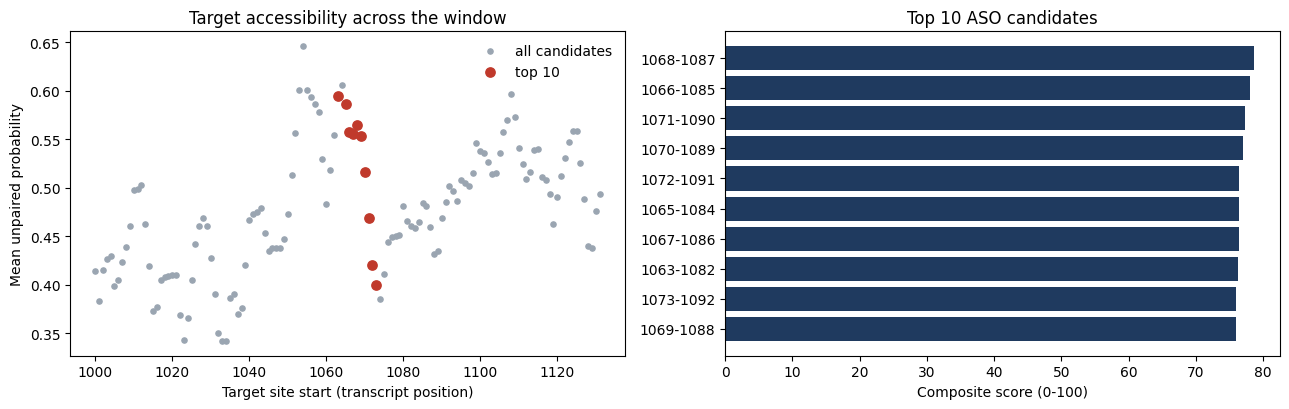

In [10]:
fig = a.plot_results(df, top_n=10)

## 7. Save results to your computer

In [11]:
df.to_csv("aso_candidates_ranked.csv", index=False)
fig.savefig("aso_top_candidates.png", dpi=200, bbox_inches="tight")
try:
    from google.colab import files
    files.download("aso_candidates_ranked.csv")
    files.download("aso_top_candidates.png")
except ImportError:
    print("Saved in the working folder (not running in Colab).")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## How the score works
40 pts target accessibility, 25 pts hybrid strength, 20 pts GC content (full marks 40-60%), 15 pts low ASO self-structure, minus 10 if GGGG is present.
The weights are my own transparent choices for prioritisation. Edit `score_candidates` in the toolkit cell to change them.

## Limitations
- ViennaRNA uses RNA energy parameters. DNA/RNA hybrids and modified chemistries (2'-MOE, PMO, LNA) behave differently.
- No off-target search inside this notebook: BLAST the top candidates at blast.ncbi.nlm.nih.gov (Nucleotide BLAST, refseq_rna, Homo sapiens).
- Only the ranking is computational. Efficacy needs experimental validation.